# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = ('/content/drive/MyDrive/Data Analyst/Python/Data/yulu_rental.csv')
df = pd.read_csv('/content/drive/MyDrive/Data Analyst/Python/Data/yulu_rental.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

In [ ]:
# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [ ]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

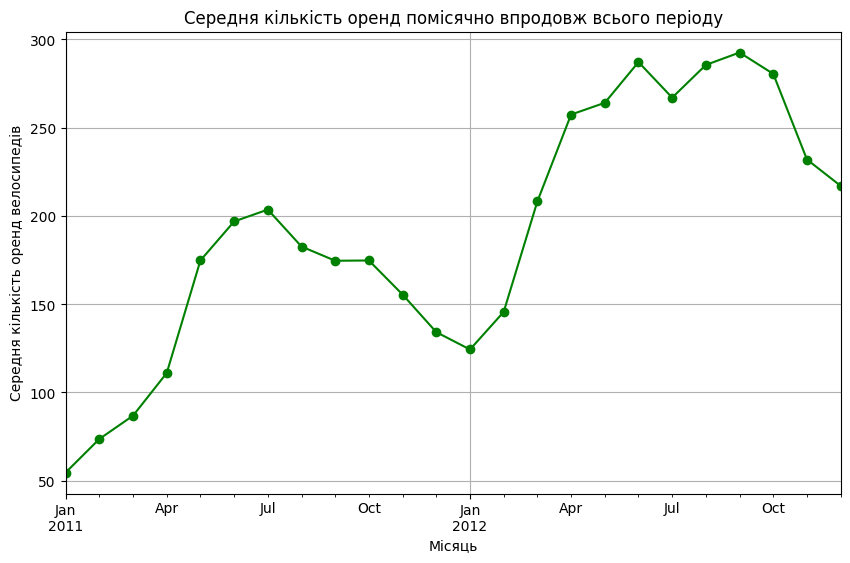

In [ ]:
# Pandas
monthly_avg = df['count'].resample('ME').mean()

monthly_avg.plot(
    figsize=(10, 6),
    marker='o',
    color='green',
    grid=True,
    title='Середня кількість оренд помісячно впродовж всього періоду',
    xlabel='Місяць',
    ylabel='Середня кількість оренд велосипедів'
)

plt.show()

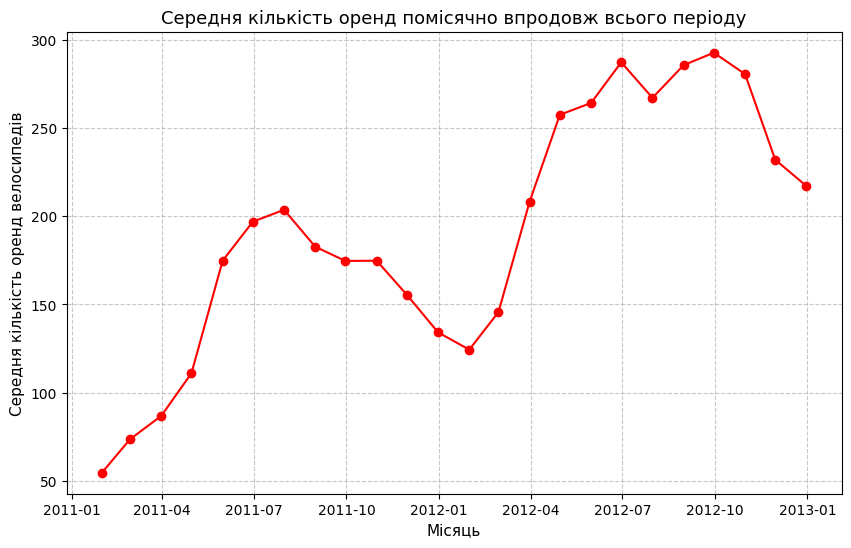

In [ ]:
# Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg, 'o-r')

plt.title('Середня кількість оренд помісячно впродовж всього періоду', fontsize=13)
plt.xlabel('Місяць', fontsize=11)
plt.ylabel('Середня кількість оренд велосипедів', fontsize=11)

plt.grid(True, alpha=0.7, linestyle='--')

plt.show()

####Відмінності:
1. В Pandas по осі X йдуть значення по назві місяця, а в Matplotlib - числове значення місяця: 2011-01, тобто Січень 2011 року.
2. В Pandas в нас графік по осі Y чітко починається з першої лінії, а в Matplotlib - невеликий відступ.
3. В Matplotlib більш зручно налаштувати графік під себе, тобто можна використати більше функцій.

В користуванні і вподабані перевагу надаю більше графіку через Matplotlib.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

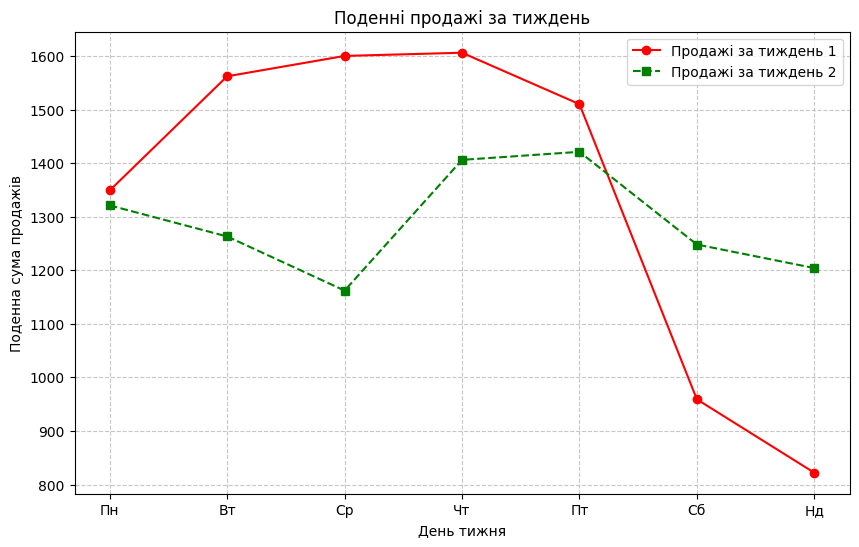

In [ ]:
plt.figure(figsize=(10, 6))

# Перша лінія
plt.plot(days, sales_week1, '-or', label='Продажі за тиждень 1')

# Друга лінія
plt.plot(days, sales_week2, '--sg', label='Продажі за тиждень 2')

plt.title('Поденні продажі за тиждень')
plt.xlabel('День тижня')
plt.ylabel('Поденна сума продажів')

plt.xticks(days, ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'])

plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')

plt.show()

1. З графіку можна зробити висновок, що тиждень 2 був стабільнішим по продажам. Зелена лінія (Тиждень 2) менш волатильна і коливається в вужчому діапазоні.

####Візуальне обґрунтування:
Тиждень 1 (червона лінія):
- Різке зростання з понеділка (1350) до четверга (1610)
- Різке падіння з п'ятниці (1510) до неділі (820)
- Амплітуда коливань: ~790 одиниць (1610 - 820)
- Лінія нестабільна — сильні підйоми та спади

Тиждень 2 (зелена пунктирна лінія):
- Невеликий спад на початку тижня (1320 → 1160)
- Плавне зростання до п'ятниці (~420)
- Невелике зниження у вихідні (1250 → 1200)
- Амплітуда коливань: ~260 одиниць (1420 - 1160)
- Лінія більш рівномірна — менші коливання

2. Є кілька статистичних метрик для вимірювання стабільності. Вони будуть наведені нижче в колонці 'Code'.

In [ ]:
# Стандартне відхилення
sales_week1 = [1349, 1562, 1600, 1606, 1510, 959, 822]
sales_week2 = [1321, 1263, 1162, 1406, 1421, 1248, 1204]

std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print(f"Стандартне відхилення Тиждень 1: {std_week1:.2f}")
print(f"Стандартне відхилення Тиждень 2: {std_week2:.2f}")

Стандартне відхилення Тиждень 1: 300.00
Стандартне відхилення Тиждень 2: 90.91


In [ ]:
# Розмах
range_week1 = max(sales_week1) - min(sales_week1)
range_week2 = max(sales_week2) - min(sales_week2)

print(f"Розмах Тиждень 1: {range_week1}")
print(f"Розмах Тиждень 2: {range_week2}")

Розмах Тиждень 1: 784
Розмах Тиждень 2: 259


In [ ]:
# Коефіцієнт варіації
mean_week1 = np.mean(sales_week1)
mean_week2 = np.mean(sales_week2)

cv_week1 = (std_week1 / mean_week1) * 100
cv_week2 = (std_week2 / mean_week2) * 100

print(f"Коефіцієнт варіації Тиждень 1: {cv_week1:.2f}%")
print(f"Коефіцієнт варіації Тиждень 2: {cv_week2:.2f}%")

Коефіцієнт варіації Тиждень 1: 22.32%
Коефіцієнт варіації Тиждень 2: 7.05%


In [ ]:
# Міжквартильний розмах
q1_week1 = np.percentile(sales_week1, 25)
q3_week1 = np.percentile(sales_week1, 75)
iqr_week1 = q3_week1 - q1_week1

q1_week2 = np.percentile(sales_week2, 25)
q3_week2 = np.percentile(sales_week2, 75)
iqr_week2 = q3_week2 - q1_week2

print(f"IQR Тиждень 1: {iqr_week1:.2f}")
print(f"IQR Тиждень 2: {iqr_week2:.2f}")

IQR Тиждень 1: 427.00
IQR Тиждень 2: 137.50


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

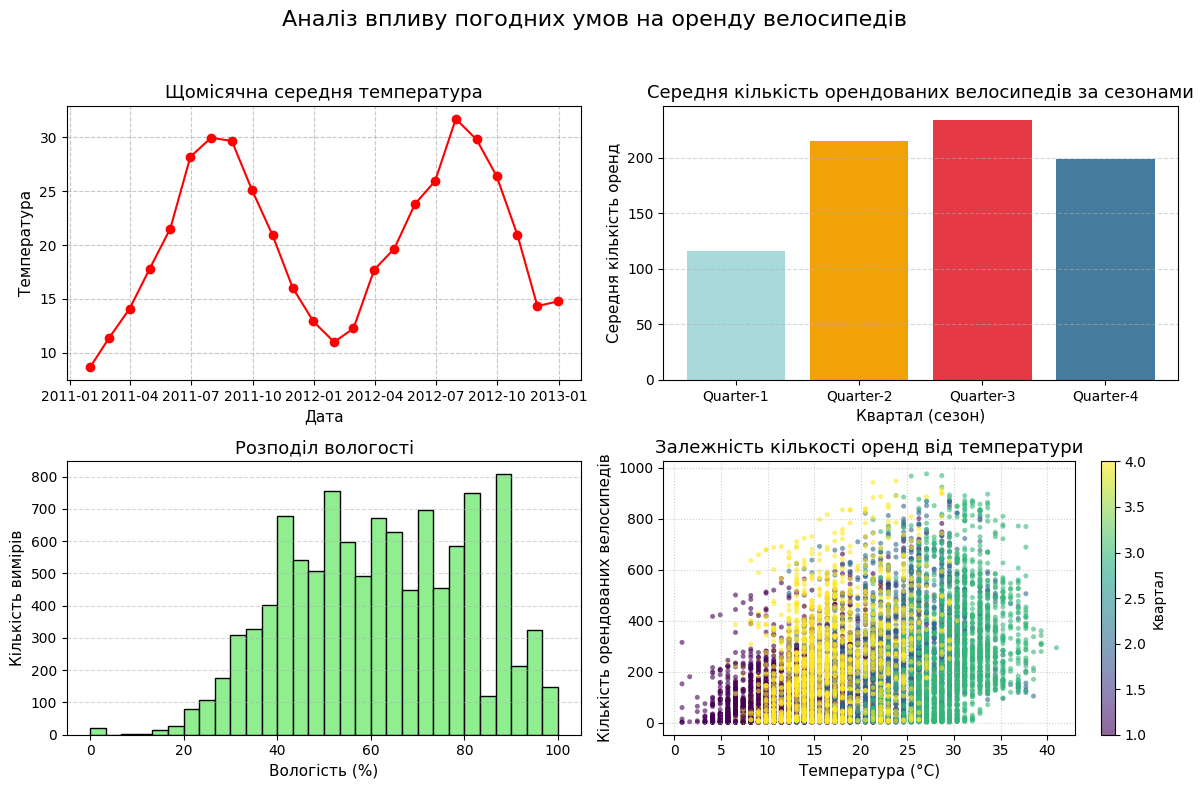

In [ ]:
temp_avg = df['temp'].resample('ME').mean()
avg_by_season = df.groupby('season')['count'].mean()

plt.figure(figsize=(12, 8))

# Лінійний графік
plt.subplot(2, 2, 1)
plt.plot(temp_avg, '-or')
plt.title('Щомісячна середня температура', fontsize=13)
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Температура', fontsize=11)
plt.grid(True, alpha=0.7, linestyle='--')

# Стовпчастий графік
plt.subplot(2, 2, 2)
plt.bar(avg_by_season.index, avg_by_season.values, color=['#A8DADC', '#F1A208', '#E63946', '#457B9D'])
plt.title('Середня кількість орендованих велосипедів за сезонами', fontsize=13)
plt.xlabel('Квартал (сезон)', fontsize=11)
plt.ylabel('Середня кількість оренд', fontsize=11)
plt.xticks([1, 2, 3, 4], ['Quarter-1', 'Quarter-2', 'Quarter-3', 'Quarter-4'])
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Гістограма
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Розподіл вологості', fontsize=13)
plt.xlabel('Вологість (%)', fontsize=11)
plt.ylabel('Кількість вимірів', fontsize=11)
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Scatter plot
plt.subplot(2, 2, 4)
plt.scatter(
    x=df['temp'], # в plt варто передавати саме масив даних
    y=df['count'],
    c=df['season'],
    alpha=0.6,
    cmap='viridis',
    s=13, # розмір точок
    edgecolors='none'
)
plt.title('Залежність кількості оренд від температури', fontsize=13)
plt.xlabel('Температура (°C)', fontsize=11)
plt.ylabel('Кількість орендованих велосипедів', fontsize=11)
cbar = plt.colorbar()
cbar.set_label('Квартал', fontsize=10)
plt.grid(True, alpha=0.6, linestyle=':')


plt.suptitle('Аналіз впливу погодних умов на оренду велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

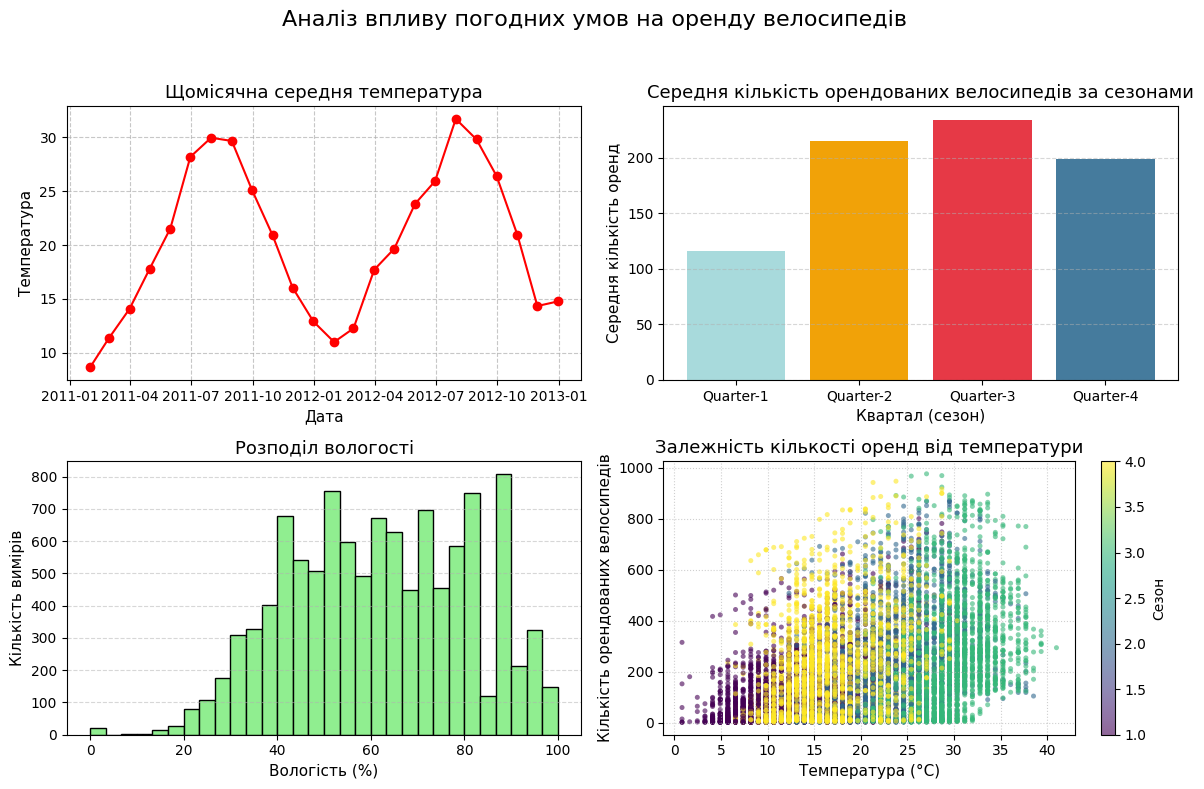

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Лінійний графік
ax[0, 0].plot(temp_avg, '-or')
ax[0, 0].set_title('Щомісячна середня температура', fontsize=13)
ax[0, 0].set_xlabel('Дата', fontsize=11)
ax[0, 0].set_ylabel('Температура', fontsize=11)
ax[0, 0].grid(True, alpha=0.7, linestyle='--')

# Стовпчастий графік
ax[0, 1].bar(avg_by_season.index, avg_by_season.values, color=['#A8DADC', '#F1A208', '#E63946', '#457B9D'])
ax[0, 1].set_title('Середня кількість орендованих велосипедів за сезонами', fontsize=13)
ax[0, 1].set_xlabel('Квартал (сезон)', fontsize=11)
ax[0, 1].set_ylabel('Середня кількість оренд', fontsize=11)
ax[0, 1].set_xticks([1, 2, 3, 4], ['Quarter-1', 'Quarter-2', 'Quarter-3', 'Quarter-4'])
ax[0, 1].grid(axis='y', alpha=0.5, linestyle='--')

# Гістограма
ax[1, 0].hist(df['humidity'], bins=30, color='lightgreen', edgecolor='black')
ax[1, 0].set_title('Розподіл вологості', fontsize=13)
ax[1, 0].set_xlabel('Вологість (%)', fontsize=11)
ax[1, 0].set_ylabel('Кількість вимірів', fontsize=11)
ax[1, 0].grid(axis='y', alpha=0.5, linestyle='--')

# Scatter plot
scatter = ax[1, 1].scatter(
    x=df['temp'], # в plt варто передавати саме масив даних
    y=df['count'],
    c=df['season'],
    alpha=0.6,
    cmap='viridis',
    s=13, # розмір точок
    edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax[1, 1])
cbar.set_label('Сезон', fontsize=10)

ax[1, 1].set_title('Залежність кількості оренд від температури', fontsize=13)
ax[1, 1].set_xlabel('Температура (°C)', fontsize=11)
ax[1, 1].set_ylabel('Кількість орендованих велосипедів', fontsize=11)
ax[1, 1].grid(True, alpha=0.6, linestyle=':')


fig.suptitle('Аналіз впливу погодних умов на оренду велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- plt.subplots() створює всю сітку графіків одразу і повертає об'єкти fig та ax, через які можна керувати кожним графіком окремо (ax[0, 0].plot(...)).
- plt.subplot() створює по одному графіку за раз, і можна працювати через глобальні функції типу plt.plot(), plt.title(). s
- subplots() дає більше контролю і зручніший для складних дашбордів, а subplot() простіший для швидких візуалізацій.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [ ]:
import matplotlib.dates as mdates

In [ ]:
monthly_avg = df['count'].resample('ME').agg(['mean', 'max', 'min'])

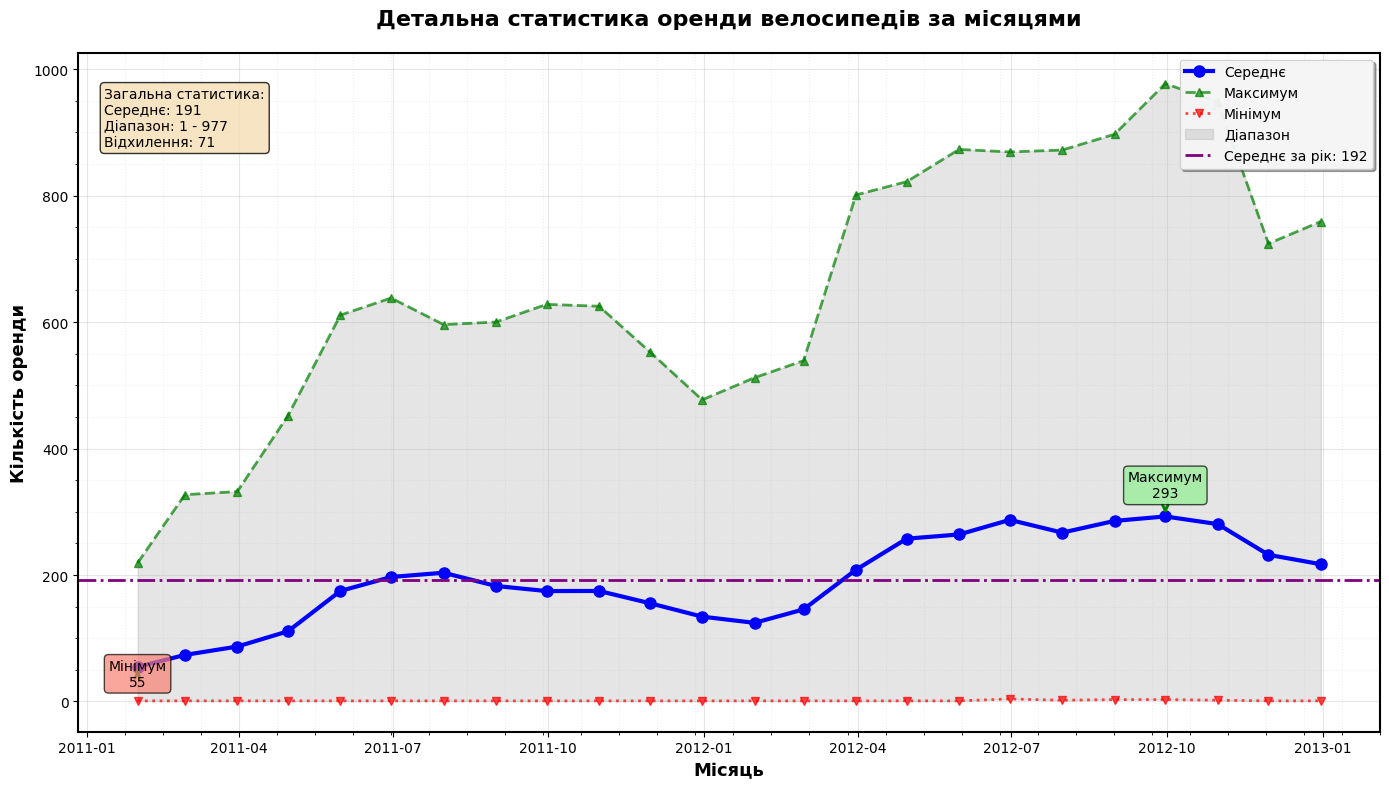

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

# Лінії з різними стилями
ax.plot(monthly_avg.index, monthly_avg['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_avg.index, monthly_avg['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_avg.index, monthly_avg['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min (правильний синтаксис)
ax.fill_between(monthly_avg.index, monthly_avg['min'], monthly_avg['max'],
                alpha=0.2, color='gray', label='Діапазон')

# Анотація для максимального середнього значення
max_idx = monthly_avg['mean'].idxmax()
max_val = monthly_avg['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 30),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))

# Анотація для мінімального середнього значення
min_idx = monthly_avg['mean'].idxmin()
min_val = monthly_avg['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val - 30),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='salmon', alpha=0.7))

# Середня лінія за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Сітка з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Стилізована легенда з тінню
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Текст з додатковою статистикою
textstr = f'Загальна статистика:\n'
textstr += f'Середнє: {monthly_avg["mean"].mean():.0f}\n'
textstr += f'Діапазон: {monthly_avg["min"].min():.0f} - {monthly_avg["max"].max():.0f}\n'
textstr += f'Відхилення: {monthly_avg["mean"].std():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Налаштування осей
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Місяць', fontsize=13, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=13, fontweight='bold')


# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()